# Unsupervised Learning

* Daten laden
* Daten explorieren
* Daten visualisieren
* Daten vorbereiten und Unsupervised Learning

In [1]:
from pandas import read_csv
from matplotlib import pyplot as plt
from seaborn import pairplot, heatmap, clustermap
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy

## Daten Laden

In [2]:
df = read_csv("titanic.csv")

## Daten Explorieren

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head(2) # und df.tail(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


## Daten Visualisieren

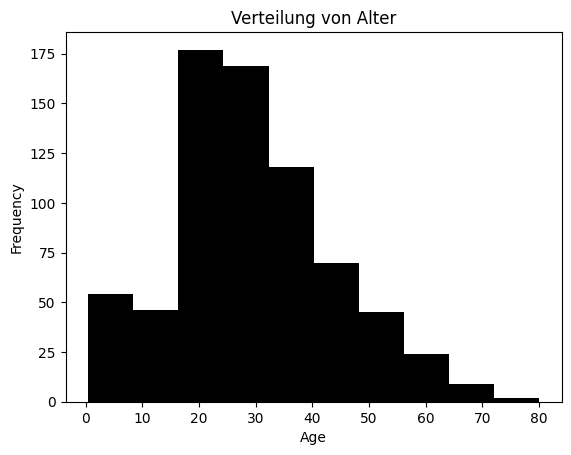

In [6]:
df["Age"].plot(kind="hist", color="k")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Verteilung von Alter")
plt.savefig("age_histogram.png")

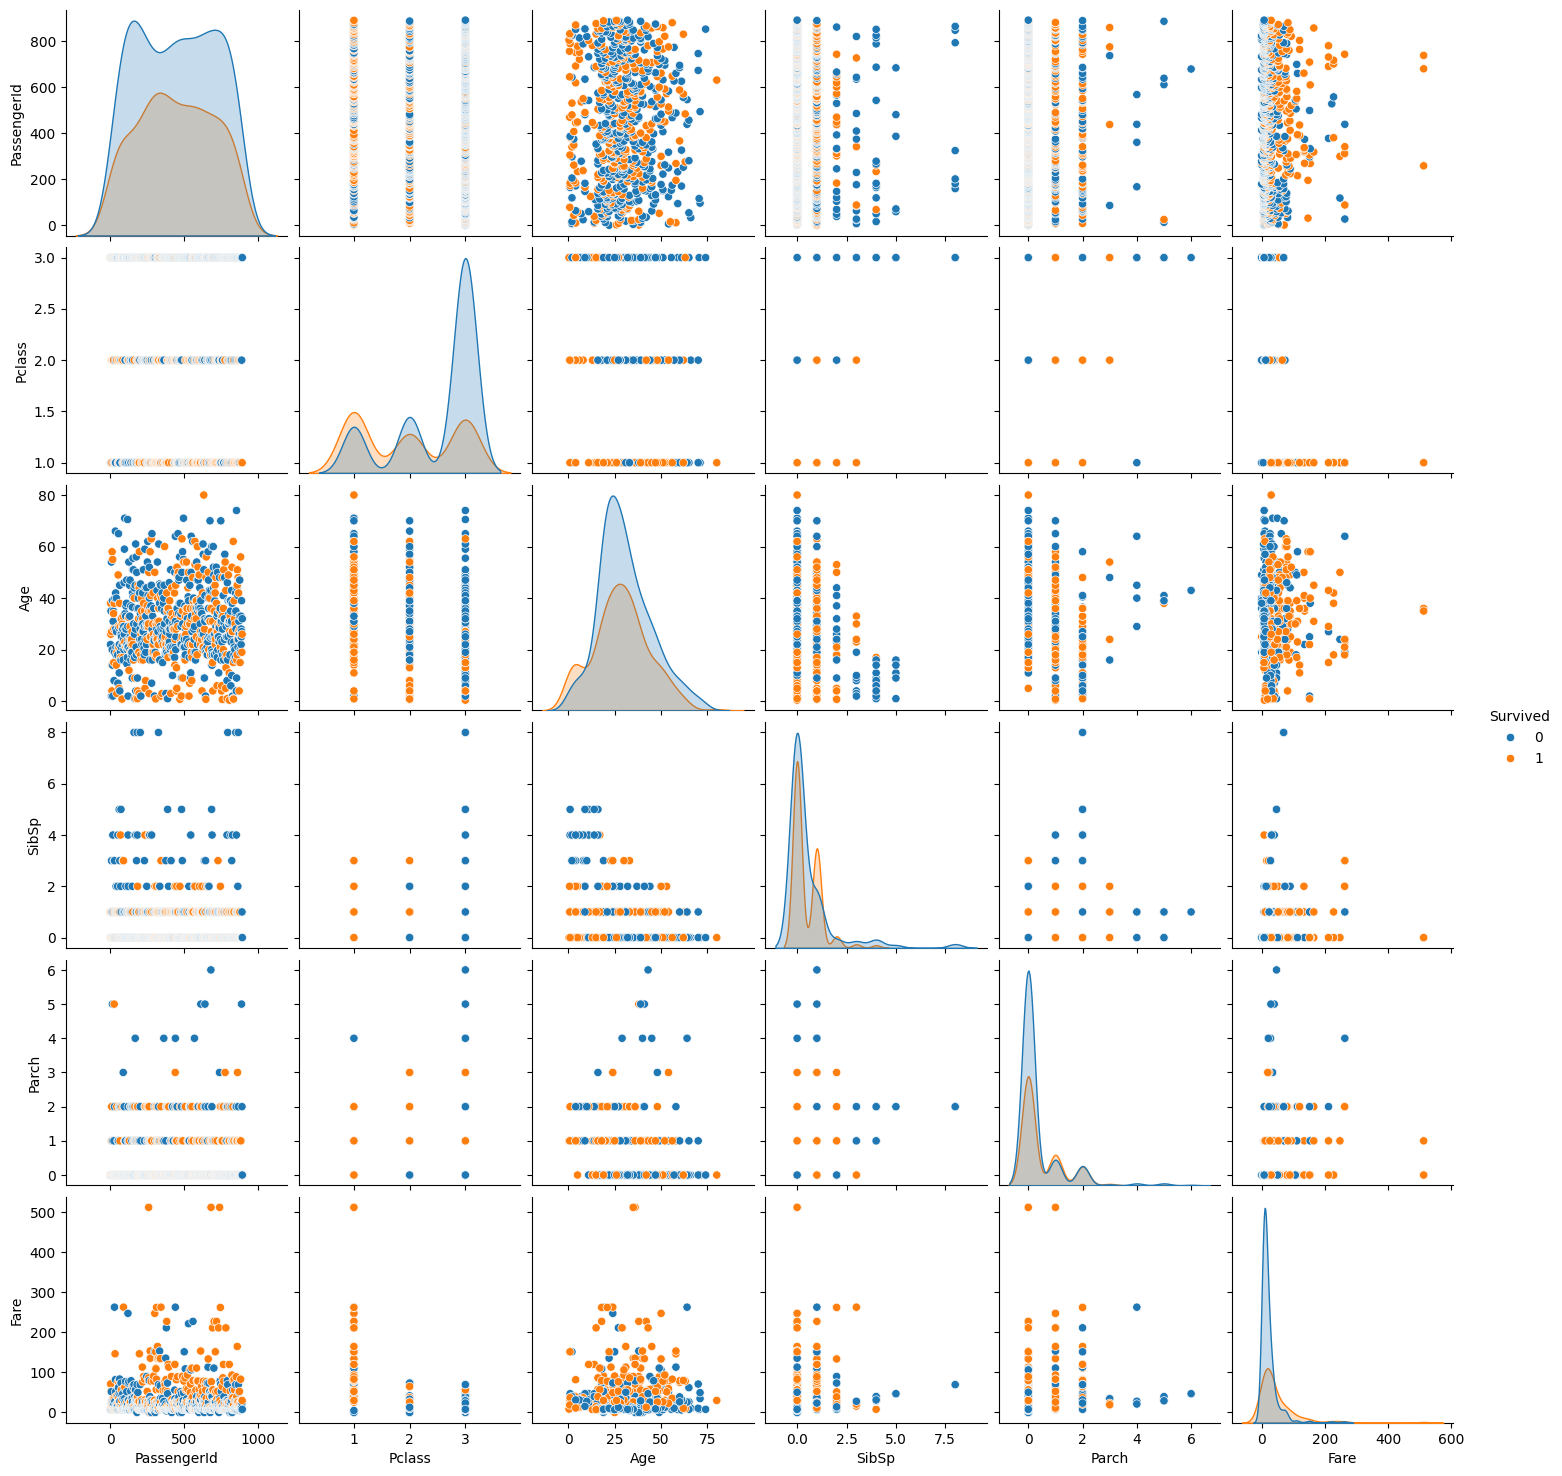

In [7]:
pairplot(df, hue="Survived")
plt.savefig("pairplot.png")

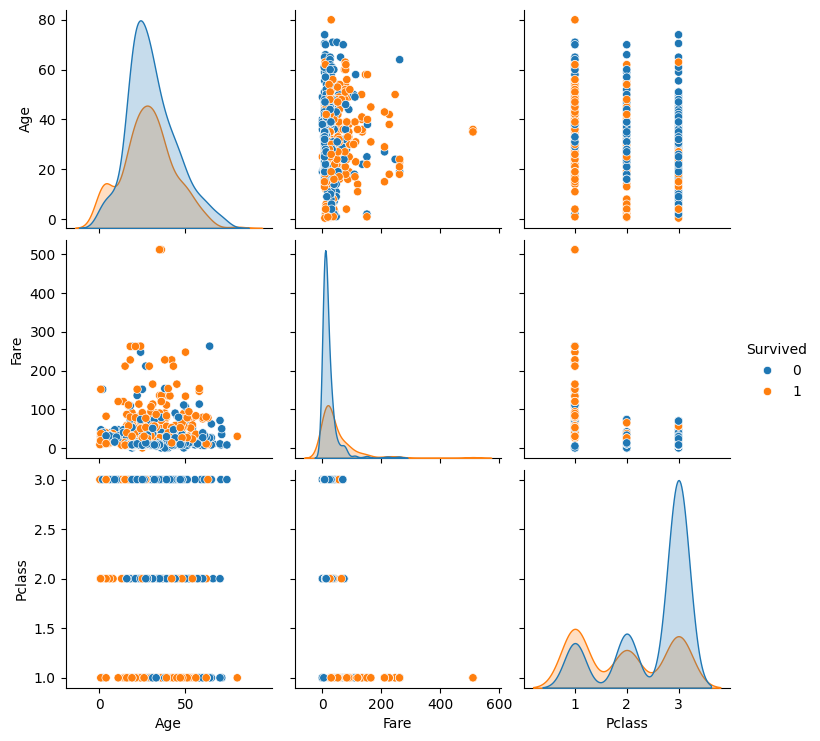

In [8]:
pairplot(df[["Age", "Fare", "Survived", "Pclass"]], hue="Survived")

In [9]:
df[["Age", "Fare"]].corr()

,Age,Fare
Age,1.000000,0.096067
Fare,0.096067,1.000000


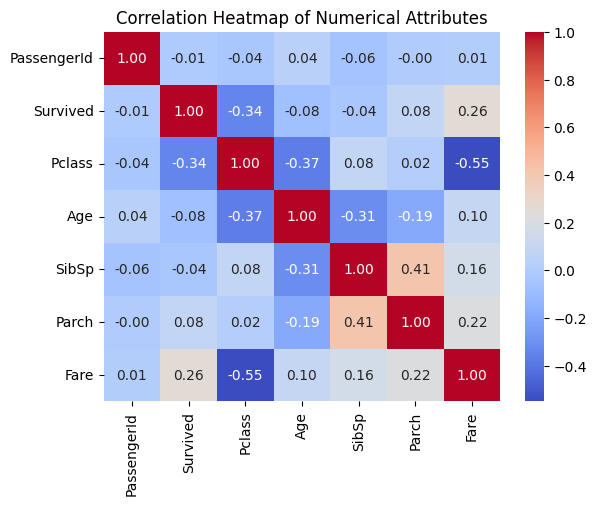

In [10]:
heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True, # Display the correlation values on the heatmap
    cmap="coolwarm", # Choose a color map
    fmt=".2f" # Format the annotation values to two decimal places
)
plt.title("Correlation Heatmap of Numerical Attributes")
plt.show()

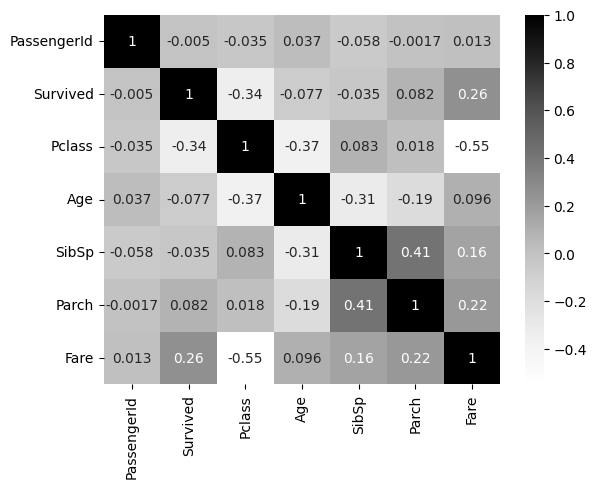

In [11]:
heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="Greys",
    annot=True
)
plt.savefig("heatmap.png")

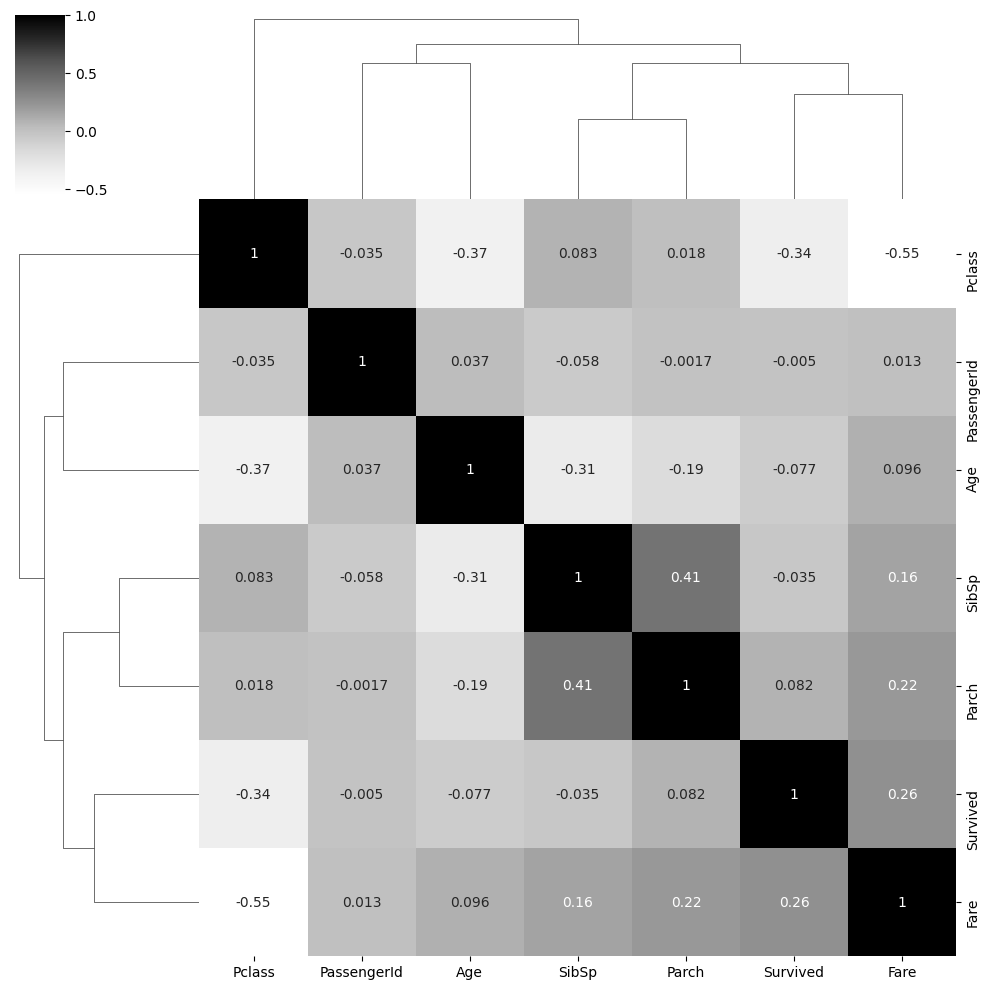

In [12]:
clustermap(
    df.select_dtypes(include="number").corr(),
    cmap="Greys",
    annot=True
)
plt.savefig("clustermap.png")

## Daten Vorbereiten für ML

* Nicht-nummerische in Nummerische Daten umwandeln
* Fehlende Werte auffüllen

In [13]:
target_colum = 'Survived'

used_columns = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch'
 ]

In [14]:
df = df[used_columns].copy()

In [15]:
# Umwandeln nicht-nummerischer Merkmale
# Bitte nur einmal ausführen
mapping_dictionary = {"female": 1, "male": 0, 0: 0, 1: 1}
df["Sex"] = df["Sex"].map(mapping_dictionary)

In [16]:
# df["Age"].fillna(-999, inplace=True)
# df["Age"].fillna(df["Age"].median(), inplace=True)
df.dropna(inplace=True)

## Unsupervised Machine Learning

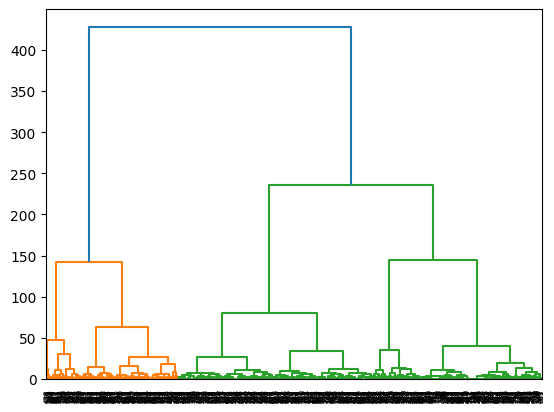

In [17]:
# Hierarchisches Clustern mit Scipy
Z = hierarchy.linkage(df, method="ward")
hierarchy.dendrogram(Z)
plt.show()

In [18]:
# Hierarchisches Clustering mit SkLearn
hierarchical_engine = AgglomerativeClustering()
hc_result = hierarchical_engine.fit_predict(df)

In [19]:
# kmeans Clustering mit SkLearn
kmeans_engine = KMeans(n_clusters=2)
km_result = kmeans_engine.fit_predict(df)

In [20]:
df["hc_result"] = hc_result
df["km_result"] = km_result

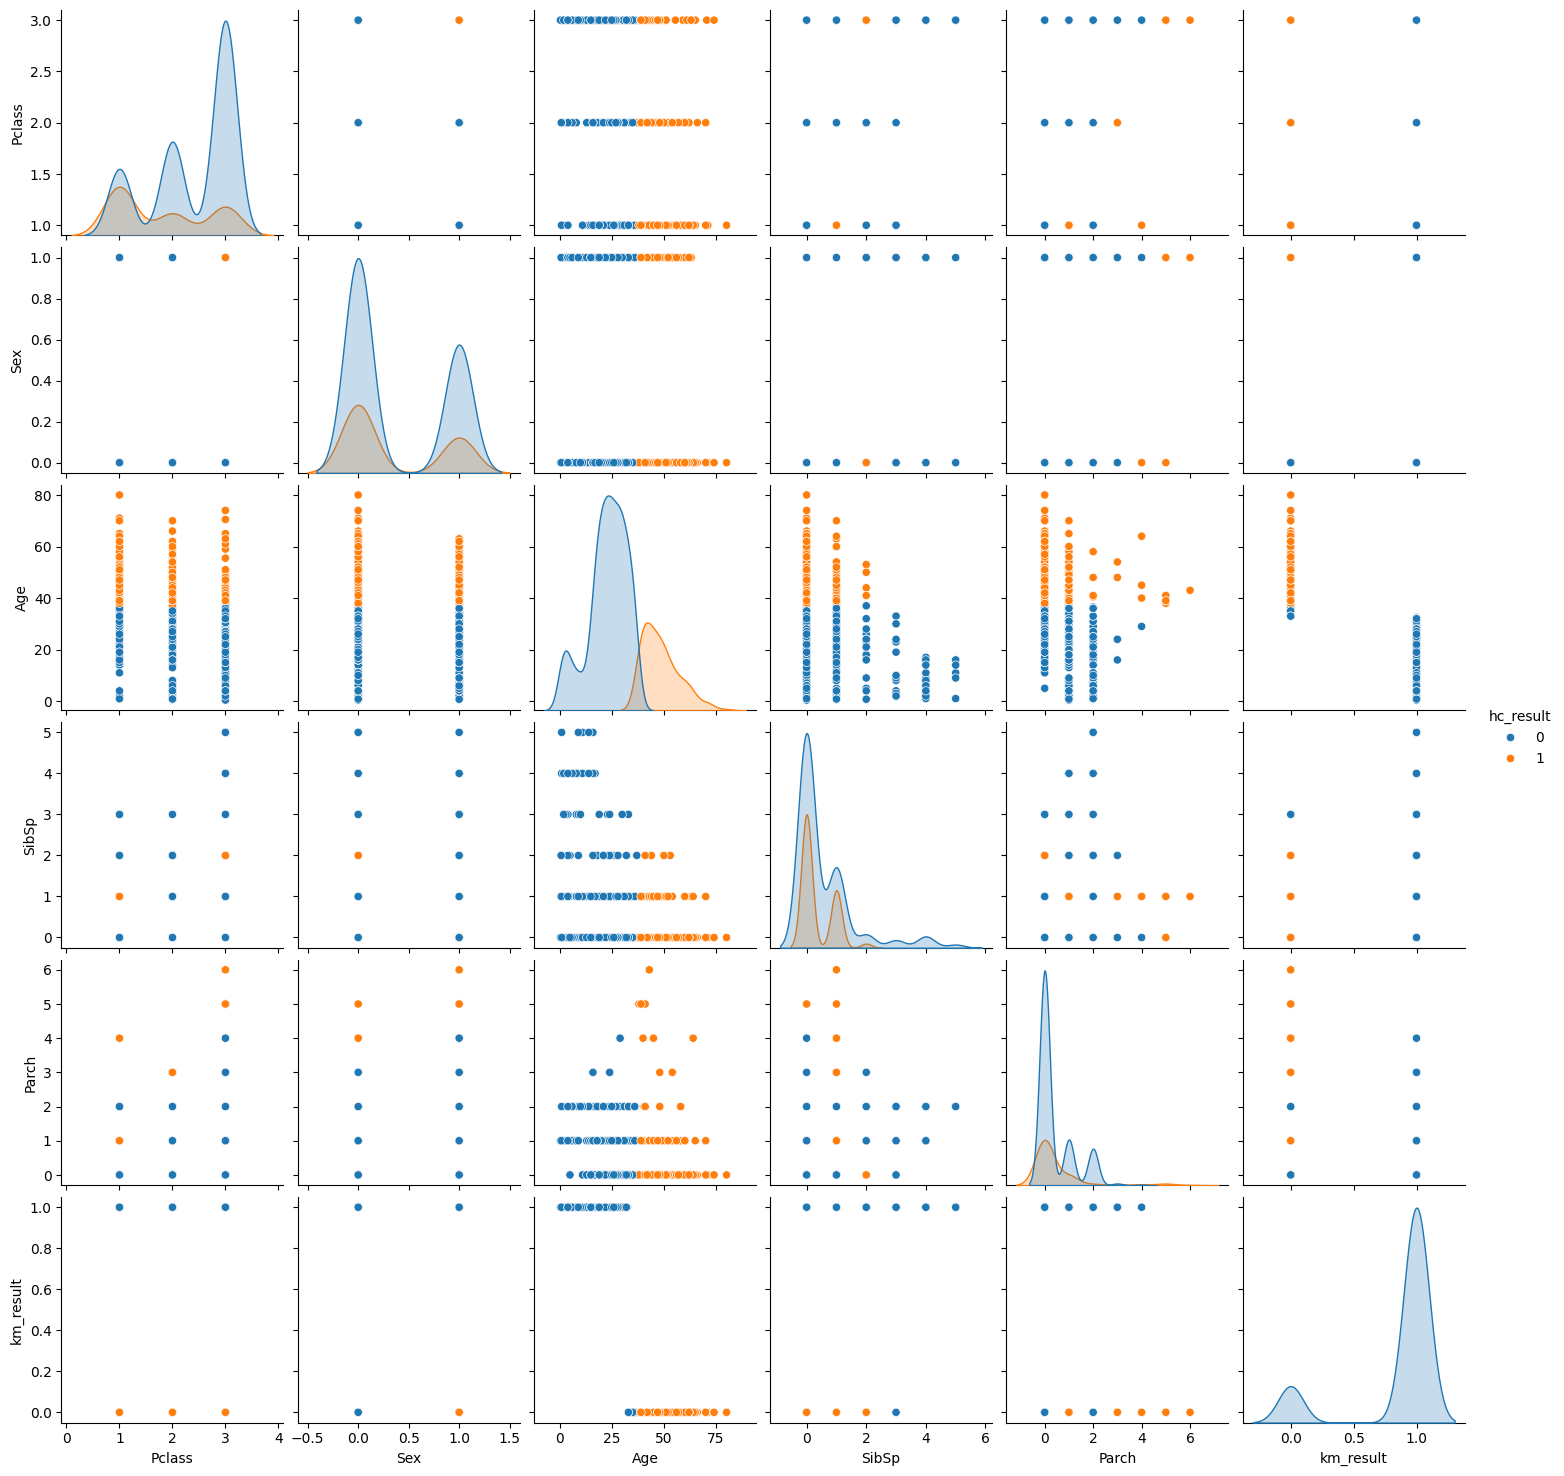

In [21]:
pairplot(df, hue="hc_result")